# Лабораторная работа №1 — Базовый ML-пайплайн

**Датасет:** образ жизни и успеваемость студентов (намеренно «испорченный»)

**Задача 1 (регрессия):** предсказать CGPA по режиму занятий и сна  
**Задача 2 (классификация):** определить риск депрессии по образу жизни и стрессу

## 0. Импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Загрузка данных

In [2]:
df_raw = pd.read_csv('student_data.csv')
print(f'{df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов')
df_raw.head()

1230 строк, 16 столбцов


,Student_ID,Age,Gender,Sleep_Duration,Study_Hours,Physical_Activity,Dietary_Habits,Social_Media_Hours,Academic_Pressure,Financial_Stress,Family_History,CGPA,Depression,CGPA_copy,Useless_Column,Random_Noise
0,1549,23.0,Female,7.269189,4.998320,2.035825,Moderate,2.949036,4.0,No,No,7.247356,1,7.247157,A,0.950330
1,1705,19.0,Male,6.055066,8.115067,4.736954,Moderate,1.120952,4.0,No,No,7.687294,0,7.687796,A,0.986683
2,1245,24.0,Male,6.489446,6.240759,NaN,NaN,2.313920,3.0,No,No,8.265698,0,8.265159,A,0.752949
3,1553,26.0,Female,5.799584,7.363880,4.690415,Moderate,2.244388,1.0,Yes,No,7.779717,0,7.777591,A,0.817456
4,2165,23.0,male,6.703369,2.689468,NaN,Moderate,4.856743,5.0,Yes,No,5.928333,1,5.927162,A,0.215616


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          1230 non-null   int64  
 1   Age                 1230 non-null   float64
 2   Gender              1230 non-null   str    
 3   Sleep_Duration      1156 non-null   float64
 4   Study_Hours         1168 non-null   float64
 5   Physical_Activity   1146 non-null   float64
 6   Dietary_Habits      1182 non-null   str    
 7   Social_Media_Hours  1230 non-null   float64
 8   Academic_Pressure   1192 non-null   float64
 9   Financial_Stress    1178 non-null   str    
 10  Family_History      1230 non-null   str    
 11  CGPA                1230 non-null   float64
 12  Depression          1230 non-null   int64  
 13  CGPA_copy           1230 non-null   float64
 14  Useless_Column      1230 non-null   str    
 15  Random_Noise        1230 non-null   float64
dtypes: float64(9), in

In [4]:
df_raw.describe()

,Student_ID,Age,Sleep_Duration,Study_Hours,Physical_Activity,Social_Media_Hours,Academic_Pressure,CGPA,Depression,CGPA_copy,Random_Noise
count,1230.000000,1230.000000,1156.000000,1168.000000,1146.000000,1230.000000,1192.000000,1230.000000,1230.000000,1230.000000,1230.000000
mean,1602.382114,22.902439,6.478425,5.083731,2.982400,3.032209,2.989933,7.283455,0.346341,7.283471,0.508259
std,346.885054,8.579419,1.744756,1.861724,1.508948,1.847199,1.393845,0.922732,0.475997,0.922749,0.294153
min,1001.000000,-3.000000,-1.000000,-1.000000,-1.715499,-2.513163,1.000000,-2.000000,0.000000,-2.000728,0.000051
25%,1303.250000,20.000000,5.599350,4.013552,1.937530,1.837263,2.000000,6.812912,0.000000,6.812540,0.254586
50%,1601.500000,23.000000,6.488606,5.012875,2.958274,2.922527,3.000000,7.287956,0.000000,7.289570,0.504077
75%,1902.750000,25.000000,7.247144,6.109103,3.906927,4.305022,4.000000,7.794984,1.000000,7.795991,0.761596
max,2200.000000,200.000000,30.000000,30.000000,8.181070,8.928937,5.000000,15.000000,1.000000,15.000346,0.999478


## 2. Разведочный анализ (EDA)

### 2.1 Пропущенные значения

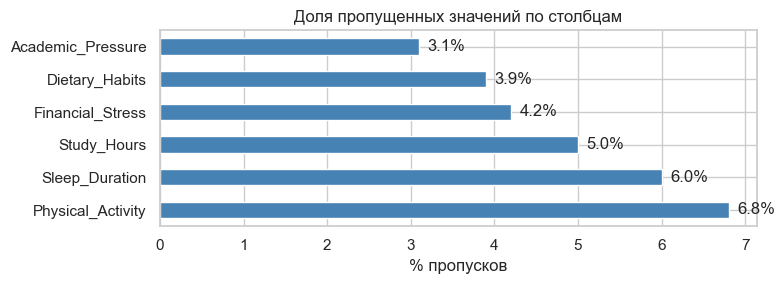

In [5]:
miss = (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
miss = miss[miss > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
miss.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% пропусков')
ax.set_title('Доля пропущенных значений по столбцам')
for i, v in enumerate(miss):
    ax.text(v + 0.1, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

### 2.2 Дубликаты и логические ошибки

In [6]:
print(f'Дубликатов: {df_raw.duplicated().sum()}')
print(f'\nAge вне [15, 45]:    {((df_raw.Age < 15) | (df_raw.Age > 45)).sum()} строк')
print(f'Sleep вне [0, 24]:   {((df_raw.Sleep_Duration < 0) | (df_raw.Sleep_Duration > 24)).sum()} строк')
print(f'CGPA вне [0, 10]:    {((df_raw.CGPA < 0) | (df_raw.CGPA > 10)).sum()} строк')
print(f'Study_Hours вне [0, 20]: {((df_raw.Study_Hours < 0) | (df_raw.Study_Hours > 20)).sum()} строк')
print(f'\nУникальные Gender: {df_raw.Gender.unique()}')

Дубликатов: 0

Age вне [15, 45]:    5 строк
Sleep вне [0, 24]:   4 строк
CGPA вне [0, 10]:    5 строк
Study_Hours вне [0, 20]: 5 строк

Уникальные Gender: <StringArray>
['Female', 'Male', 'male', 'FEMALE', 'M']
Length: 5, dtype: str


### 2.3 Распределения числовых признаков

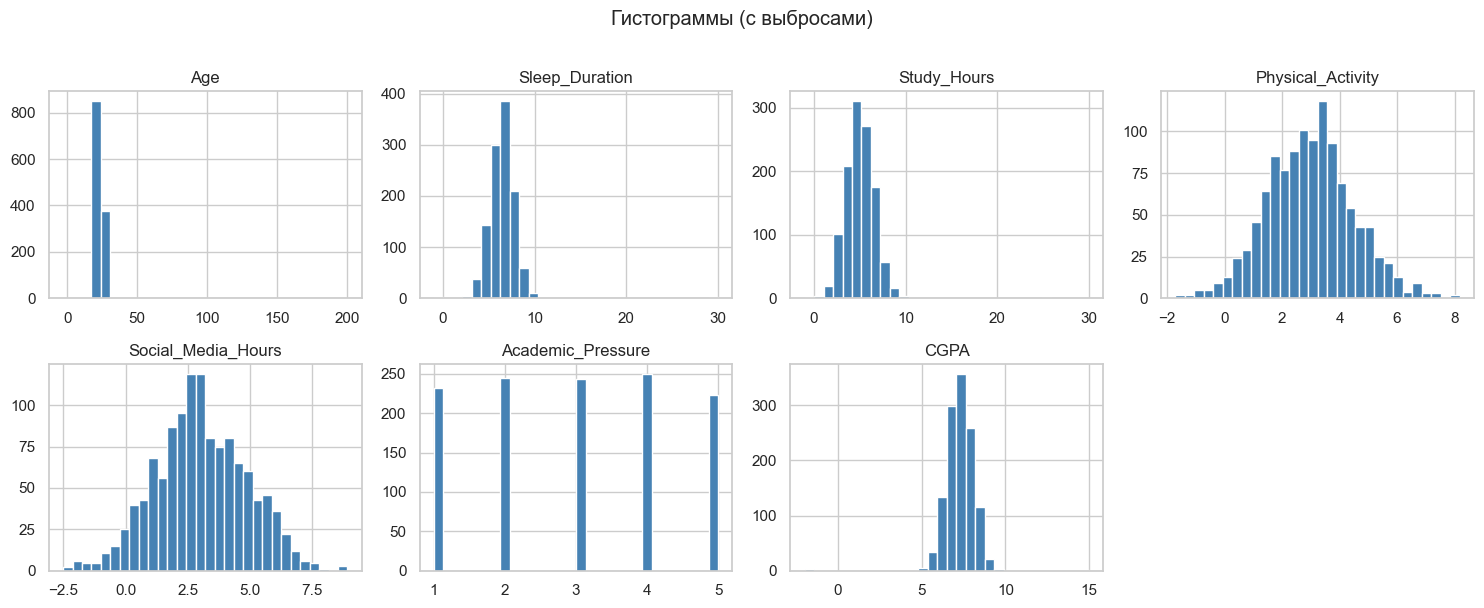

In [7]:
num_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
            'Social_Media_Hours', 'Academic_Pressure', 'CGPA']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flatten(), num_cols):
    df_raw[col].dropna().hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Гистограммы (с выбросами)', y=1.01)
plt.tight_layout()
plt.show()

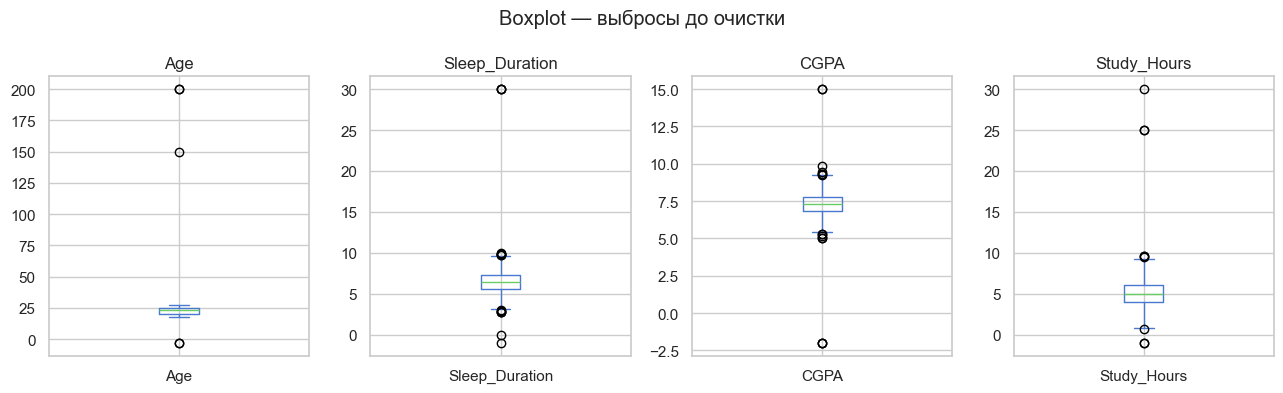

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, col in zip(axes, ['Age', 'Sleep_Duration', 'CGPA', 'Study_Hours']):
    df_raw[col].dropna().plot.box(ax=ax)
    ax.set_title(col)
plt.suptitle('Boxplot — выбросы до очистки')
plt.tight_layout()
plt.show()

### 2.4 Категориальные признаки и баланс классов

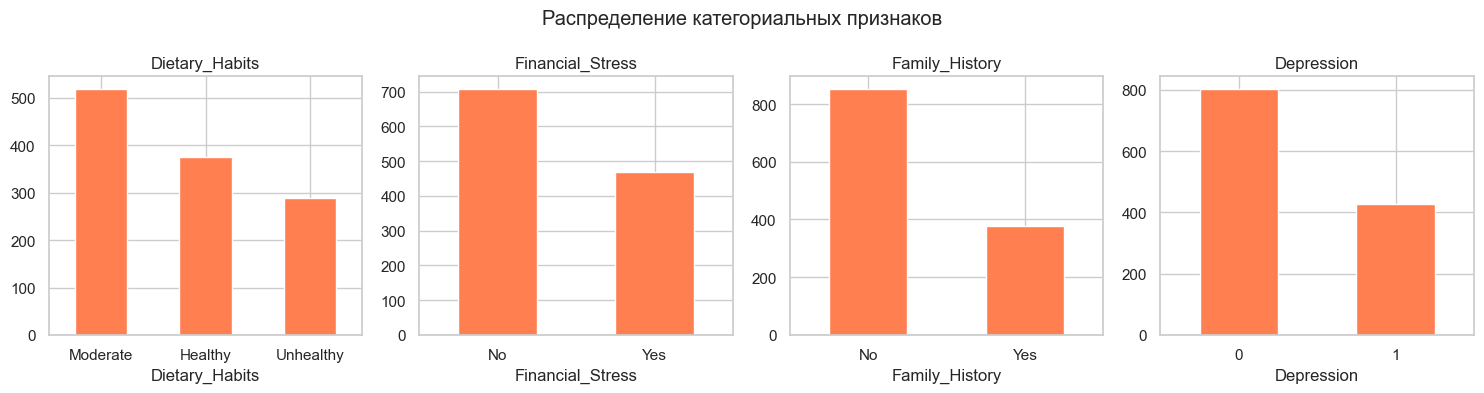

Depression — 0: 804, 1: 426, доля позитивных: 34.6%


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, ['Dietary_Habits', 'Financial_Stress', 'Family_History', 'Depression']):
    df_raw[col].value_counts().plot.bar(ax=ax, color='coral', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Распределение категориальных признаков')
plt.tight_layout()
plt.show()

vc = df_raw['Depression'].value_counts()
print(f'Depression — 0: {vc[0]}, 1: {vc[1]}, доля позитивных: {vc[1]/len(df_raw):.1%}')

### 2.5 Корреляция и связь признаков с таргетами

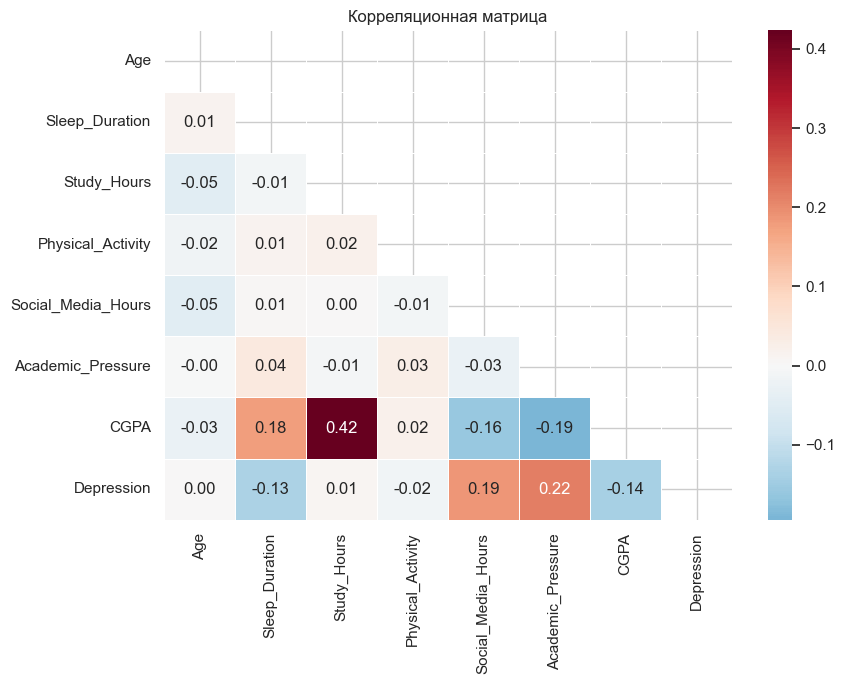

In [10]:
corr_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
             'Social_Media_Hours', 'Academic_Pressure', 'CGPA', 'Depression']
corr = df_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('Корреляционная матрица')
plt.tight_layout()
plt.show()

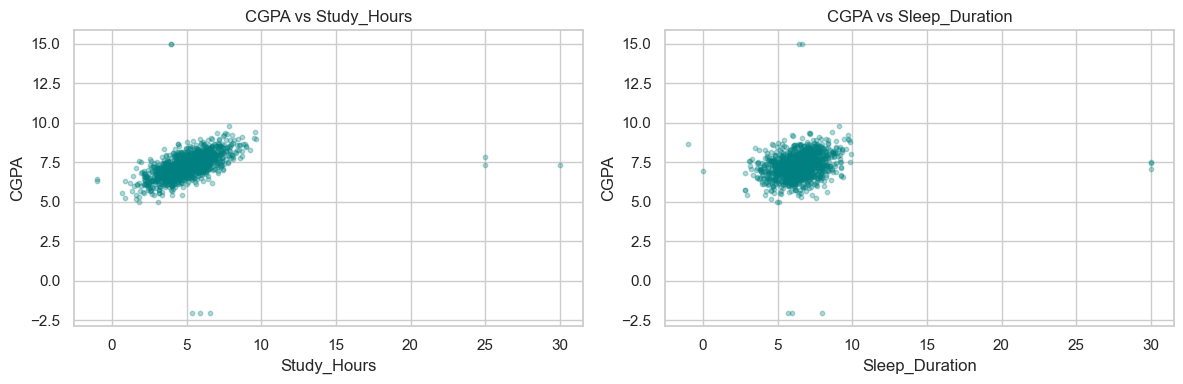

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Study_Hours', 'Sleep_Duration']):
    ax.scatter(df_raw[col], df_raw['CGPA'], alpha=0.3, s=10, color='teal')
    ax.set_xlabel(col)
    ax.set_ylabel('CGPA')
    ax.set_title(f'CGPA vs {col}')
plt.tight_layout()
plt.show()

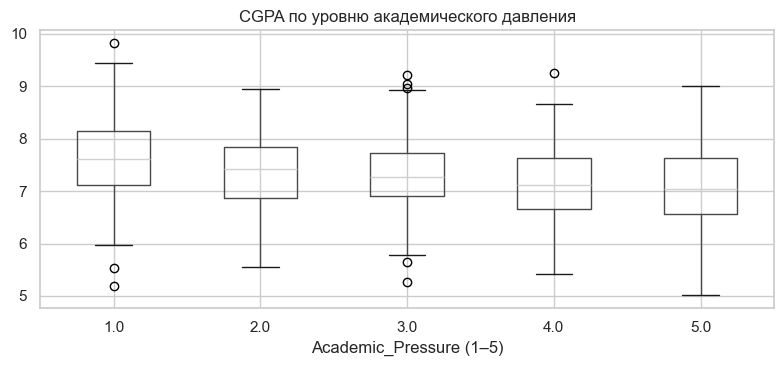

In [12]:
valid = df_raw[(df_raw.CGPA >= 4) & (df_raw.CGPA <= 10)]
fig, ax = plt.subplots(figsize=(8, 4))
valid.boxplot('CGPA', by='Academic_Pressure', ax=ax)
ax.set_title('CGPA по уровню академического давления')
ax.set_xlabel('Academic_Pressure (1–5)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 3. Предобработка

Найденные проблемы и способы исправления:

| Проблема | Решение |
|---|---|
| Дубликаты строк | удаление |
| Константный и шумовой столбцы (`Useless_Column`, `Random_Noise`) | удаление |
| `CGPA_copy` — почти идентичная копия `CGPA` | удаление (утечка данных) |
| `Student_ID` — идентификатор | удаление |
| Нереалистичные значения Age / Sleep / CGPA / Study_Hours | замена на NaN |
| Несогласованный формат Gender ("male", "M", "FEMALE") | нормализация |
| Пропуски в 6 столбцах | медиана / мода |

In [13]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
print(f'Удалено дубликатов: {before - len(df)}')

df = df.drop(columns=['Student_ID', 'Useless_Column', 'Random_Noise', 'CGPA_copy'])

Удалено дубликатов: 0


In [14]:
df.loc[(df.Age < 15) | (df.Age > 45), 'Age'] = np.nan
df.loc[(df.Sleep_Duration < 0) | (df.Sleep_Duration > 24), 'Sleep_Duration'] = np.nan
df.loc[(df.CGPA < 0) | (df.CGPA > 10), 'CGPA'] = np.nan
df.loc[(df.Study_Hours < 0) | (df.Study_Hours > 20), 'Study_Hours'] = np.nan

print(df.isnull().sum()[df.isnull().sum() > 0])

Age                   5
Sleep_Duration       78
Study_Hours          67
Physical_Activity    84
Dietary_Habits       48
Academic_Pressure    38
Financial_Stress     52
CGPA                  5
dtype: int64


In [15]:
def normalize_gender(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ('male', 'm'):
        return 'Male'
    if v in ('female', 'f'):
        return 'Female'
    return np.nan

df['Gender'] = df['Gender'].apply(normalize_gender)
print(df['Gender'].value_counts())

Gender
Male      646
Female    584
Name: count, dtype: int64


In [16]:
num_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
            'Social_Media_Hours', 'Academic_Pressure', 'CGPA']
cat_cols = ['Gender', 'Dietary_Habits', 'Financial_Stress', 'Family_History']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Пропусков осталось: {df.isnull().sum().sum()}')

Пропусков осталось: 0


In [17]:
for col in ['Financial_Stress', 'Family_History']:
    df[col] = (df[col] == 'Yes').astype(int)

df['Gender'] = (df['Gender'] == 'Female').astype(int)
df['Dietary_Habits'] = df['Dietary_Habits'].map({'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2})

print(df.dtypes)

Age                   float64
Gender                  int64
Sleep_Duration        float64
Study_Hours           float64
Physical_Activity     float64
Dietary_Habits          int64
Social_Media_Hours    float64
Academic_Pressure     float64
Financial_Stress        int64
Family_History          int64
CGPA                  float64
Depression              int64
dtype: object


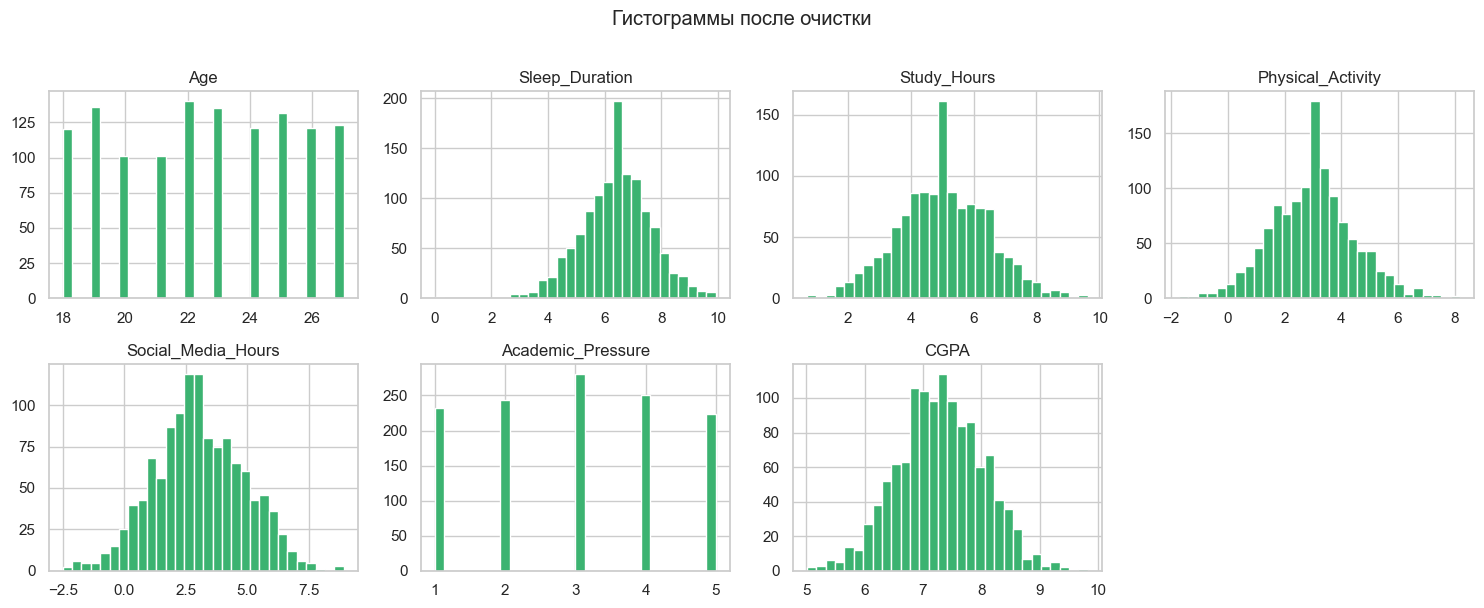

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(ax=ax, bins=30, color='mediumseagreen', edgecolor='white')
    ax.set_title(col)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Гистограммы после очистки', y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Добавляем три новых признака:
- `Study_Sleep_Ratio` — соотношение часов учёбы и сна
- `Lifestyle_Score` — сон, физнагрузка и питание в одном числе
- `Stress_Load` — давление + финансы + соцсети

Отбор через Mutual Information.

In [19]:
df['Study_Sleep_Ratio'] = df['Study_Hours'] / (df['Sleep_Duration'] + 0.1)
df['Lifestyle_Score']   = df['Sleep_Duration'] * 0.3 + df['Physical_Activity'] * 0.3 + df['Dietary_Habits'] * 0.4
df['Stress_Load']       = df['Academic_Pressure'] + df['Financial_Stress'] + df['Social_Media_Hours'] * 0.2

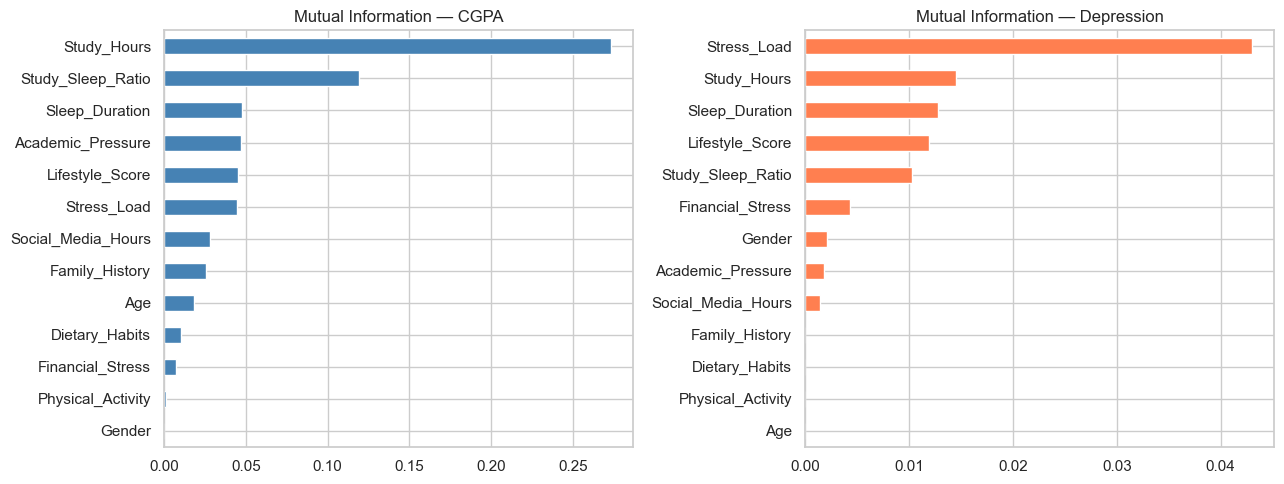

In [20]:
all_features = [
    'Age', 'Gender', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
    'Dietary_Habits', 'Social_Media_Hours', 'Academic_Pressure',
    'Financial_Stress', 'Family_History',
    'Study_Sleep_Ratio', 'Lifestyle_Score', 'Stress_Load'
]

mi_reg = pd.Series(mutual_info_regression(df[all_features], df['CGPA'], random_state=SEED),
                   index=all_features).sort_values()
mi_clf = pd.Series(mutual_info_classif(df[all_features], df['Depression'], random_state=SEED),
                   index=all_features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mi_reg.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information — CGPA')
mi_clf.plot.barh(ax=axes[1], color='coral')
axes[1].set_title('Mutual Information — Depression')
plt.tight_layout()
plt.show()

По результатам MI выбираем признаки:
- **Регрессия:** `Sleep_Duration`, `Study_Hours`, `Study_Sleep_Ratio` (условие задачи + наивысший MI)
- **Классификация:** `Academic_Pressure`, `Sleep_Duration`, `Social_Media_Hours`, `Financial_Stress`, `Family_History`, `Physical_Activity`, `Dietary_Habits`, `Lifestyle_Score`, `Stress_Load`

In [21]:
REG_FEATURES = ['Sleep_Duration', 'Study_Hours', 'Study_Sleep_Ratio']

CLF_FEATURES = [
    'Academic_Pressure', 'Sleep_Duration', 'Social_Media_Hours',
    'Financial_Stress', 'Family_History', 'Physical_Activity',
    'Dietary_Habits', 'Lifestyle_Score', 'Stress_Load'
]

## 5. Разбивка данных (60 / 20 / 20)

In [22]:
def make_splits(X, y, seed=SEED):
    X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=seed)
    return X_train, X_val, X_test, y_train, y_val, y_test

def scale(X_train, X_val, X_test):
    sc = StandardScaler()
    return sc.fit_transform(X_train), sc.transform(X_val), sc.transform(X_test)

X_reg = df[REG_FEATURES].values
y_reg = df['CGPA'].values
X_reg_train, X_reg_val, X_reg_test, y_reg_train, y_reg_val, y_reg_test = make_splits(X_reg, y_reg)
X_reg_train, X_reg_val, X_reg_test = scale(X_reg_train, X_reg_val, X_reg_test)

X_clf = df[CLF_FEATURES].values
y_clf = df['Depression'].values
X_clf_train, X_clf_val, X_clf_test, y_clf_train, y_clf_val, y_clf_test = make_splits(X_clf, y_clf)
X_clf_train, X_clf_val, X_clf_test = scale(X_clf_train, X_clf_val, X_clf_test)

print('Регрессия  train/val/test:', X_reg_train.shape[0], X_reg_val.shape[0], X_reg_test.shape[0])
print('Классификация train/val/test:', X_clf_train.shape[0], X_clf_val.shape[0], X_clf_test.shape[0])

Регрессия  train/val/test: 738 246 246
Классификация train/val/test: 738 246 246


## 6. Линейная регрессия — прогноз CGPA

In [23]:
lin = LinearRegression()
lin.fit(X_reg_train, y_reg_train)

def reg_report(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:6s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return rmse, mae, r2

reg_report(y_reg_train, lin.predict(X_reg_train), 'Train')
reg_report(y_reg_val,   lin.predict(X_reg_val),   'Val')
rmse_t, mae_t, r2_t = reg_report(y_reg_test, lin.predict(X_reg_test), 'Test')

for f, c in zip(REG_FEATURES, lin.coef_):
    print(f'  {f}: {c:.4f}')

Train   RMSE=0.4884  MAE=0.3929  R²=0.5629
Val     RMSE=0.6665  MAE=0.4453  R²=0.2083
Test    RMSE=0.5094  MAE=0.4030  R²=0.4979
  Sleep_Duration: 0.2520
  Study_Hours: 0.4749
  Study_Sleep_Ratio: 0.0353


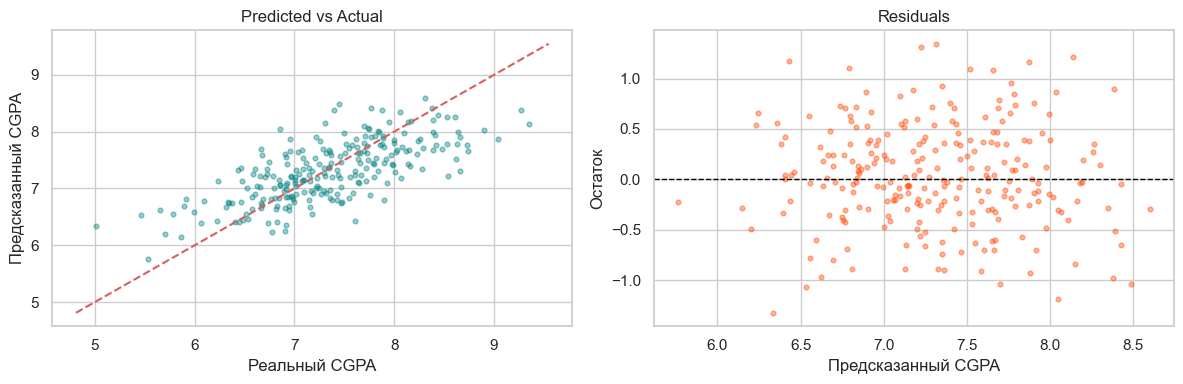

In [24]:
y_pred_test = lin.predict(X_reg_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_reg_test, y_pred_test, alpha=0.4, s=12, color='teal')
lim = [min(y_reg_test.min(), y_pred_test.min()) - 0.2,
       max(y_reg_test.max(), y_pred_test.max()) + 0.2]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlabel('Реальный CGPA')
axes[0].set_ylabel('Предсказанный CGPA')
axes[0].set_title('Predicted vs Actual')

residuals = y_reg_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=12, color='orangered')
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Предсказанный CGPA')
axes[1].set_ylabel('Остаток')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

## 7. Логистическая регрессия — классификация Depression

### 7.1 Эксперимент: learning rate × число эпох

In [25]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs_list    = [10, 50, 100, 200, 500]
results = []

for lr in learning_rates:
    for epochs in epochs_list:
        clf = SGDClassifier(
            loss='log_loss', learning_rate='constant', eta0=lr,
            max_iter=epochs, class_weight='balanced',
            random_state=SEED, tol=None
        )
        clf.fit(X_clf_train, y_clf_train)
        results.append({
            'lr': lr, 'epochs': epochs,
            'train_acc': accuracy_score(y_clf_train, clf.predict(X_clf_train)),
            'val_acc':   accuracy_score(y_clf_val, clf.predict(X_clf_val)),
            'val_f1':    f1_score(y_clf_val, clf.predict(X_clf_val), zero_division=0)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

    lr  epochs  train_acc  val_acc   val_f1
0.1000      10   0.649051 0.609756 0.494737
0.1000      50   0.673442 0.638211 0.508287
0.1000     100   0.655827 0.626016 0.540000
0.1000     200   0.657182 0.642276 0.511111
0.1000     500   0.647696 0.642276 0.476190
0.0100      10   0.653117 0.597561 0.497462
0.0100      50   0.654472 0.597561 0.492308
0.0100     100   0.655827 0.601626 0.500000
0.0100     200   0.655827 0.609756 0.510204
0.0100     500   0.658537 0.601626 0.510000
0.0010      10   0.650407 0.589431 0.492462
0.0010      50   0.663957 0.609756 0.505155
0.0010     100   0.662602 0.609756 0.505155
0.0010     200   0.661247 0.609756 0.505155
0.0010     500   0.662602 0.609756 0.505155
0.0001      10   0.639566 0.597561 0.517073
0.0001      50   0.644986 0.593496 0.504950
0.0001     100   0.650407 0.589431 0.492462
0.0001     200   0.657182 0.605691 0.502564
0.0001     500   0.662602 0.609756 0.505155


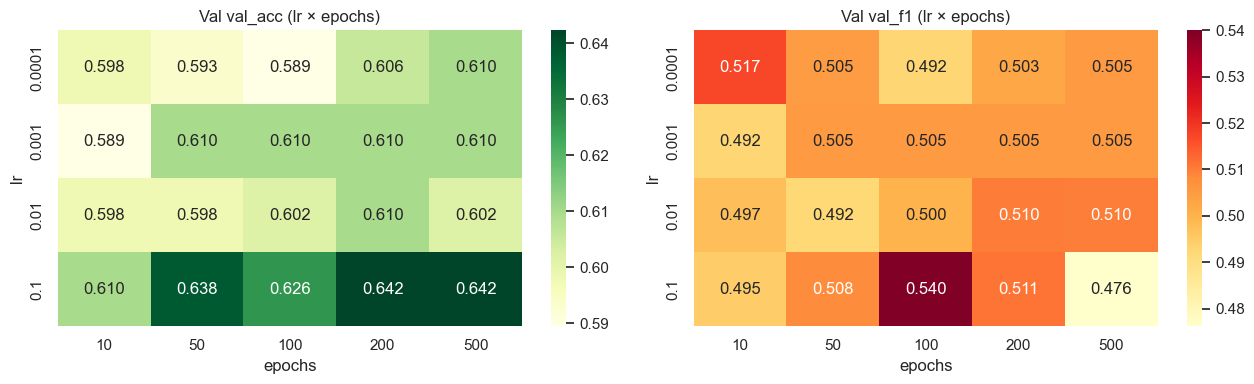

lr=0.1, epochs=100 → val_acc=0.626, val_f1=0.540


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, cmap in zip(axes, ['val_acc', 'val_f1'], ['YlGn', 'YlOrRd']):
    pivot = results_df.pivot(index='lr', columns='epochs', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax)
    ax.set_title(f'Val {metric} (lr × epochs)')
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['val_f1'].idxmax()]
print(f'lr={best.lr}, epochs={int(best.epochs)} → val_acc={best.val_acc:.3f}, val_f1={best.val_f1:.3f}')

### 7.2 Train vs Val по эпохам

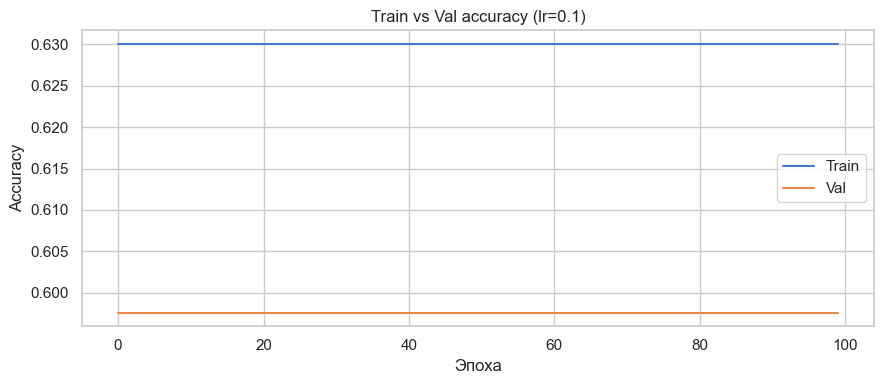

разрыв train–val: макс=0.0325, последняя эпоха=0.0325


In [27]:
best_lr     = float(best.lr)
best_epochs = int(best.epochs)
train_accs, val_accs = [], []

clf_track = SGDClassifier(
    loss='log_loss', learning_rate='constant', eta0=best_lr,
    max_iter=1, warm_start=True, class_weight='balanced',
    random_state=SEED, tol=None
)
for _ in range(best_epochs):
    clf_track.fit(X_clf_train, y_clf_train)
    train_accs.append(accuracy_score(y_clf_train, clf_track.predict(X_clf_train)))
    val_accs.append(accuracy_score(y_clf_val, clf_track.predict(X_clf_val)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_accs, label='Train')
ax.plot(val_accs,   label='Val')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Accuracy')
ax.set_title(f'Train vs Val accuracy (lr={best_lr})')
ax.legend()
plt.tight_layout()
plt.show()

gap = np.array(train_accs) - np.array(val_accs)
print(f'разрыв train–val: макс={gap.max():.4f}, последняя эпоха={gap[-1]:.4f}')

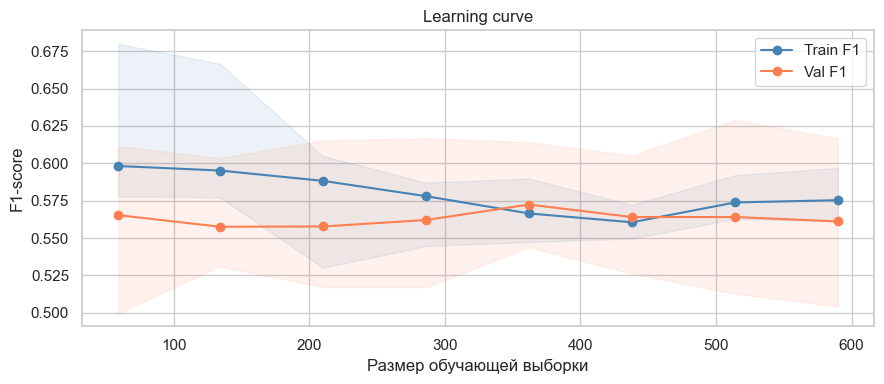

разрыв train/val f1 на полной выборке: 0.0142


In [28]:
clf_lc = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
train_sizes, train_scores, val_scores = learning_curve(
    clf_lc, X_clf_train, y_clf_train,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=SEED
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(train_sizes, train_scores.min(1), train_scores.max(1), alpha=0.1, color='steelblue')
ax.fill_between(train_sizes, val_scores.min(1),   val_scores.max(1),   alpha=0.1, color='coral')
ax.plot(train_sizes, train_scores.mean(1), 'o-', color='steelblue', label='Train F1')
ax.plot(train_sizes, val_scores.mean(1),   'o-', color='coral',     label='Val F1')
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('F1-score')
ax.set_title('Learning curve')
ax.legend()
plt.tight_layout()
plt.show()

final_gap = abs(train_scores.mean(1)[-1] - val_scores.mean(1)[-1])
print(f'разрыв train/val f1 на полной выборке: {final_gap:.4f}')

## 8. Финальная оценка на тестовой выборке

In [29]:
rmse_t, mae_t, r2_t = reg_report(y_reg_test, lin.predict(X_reg_test), 'Test')

Test    RMSE=0.5094  MAE=0.4030  R²=0.4979


In [30]:
clf_final = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
clf_final.fit(X_clf_train, y_clf_train)

y_pred  = clf_final.predict(X_clf_test)
y_proba = clf_final.predict_proba(X_clf_test)[:, 1]

acc  = accuracy_score(y_clf_test, y_pred)
prec = precision_score(y_clf_test, y_pred, zero_division=0)
rec  = recall_score(y_clf_test, y_pred, zero_division=0)
f1   = f1_score(y_clf_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_clf_test, y_proba)

print(f'accuracy={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}  roc_auc={auc:.3f}')

accuracy=0.638  precision=0.481  recall=0.588  f1=0.529  roc_auc=0.699


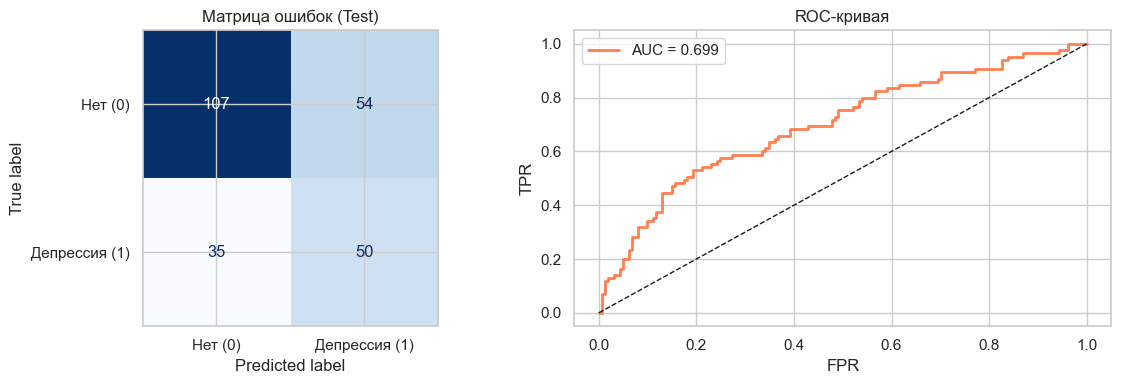

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_clf_test, y_pred),
                       display_labels=['Нет (0)', 'Депрессия (1)']
                       ).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Матрица ошибок (Test)')

fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='coral', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

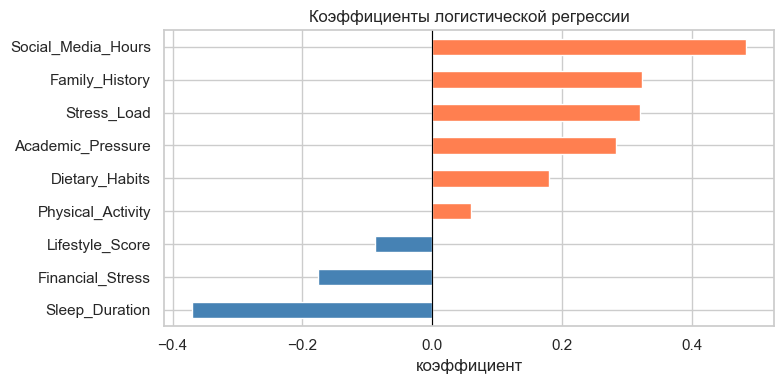

In [32]:
coef = pd.Series(clf_final.coef_[0], index=CLF_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
coef.plot.barh(ax=ax, color=['coral' if v > 0 else 'steelblue' for v in coef])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Коэффициенты логистической регрессии')
ax.set_xlabel('коэффициент')
plt.tight_layout()
plt.show()

## 9. Выводы

**Линейная регрессия (CGPA):** R² ≈ 0.50, RMSE ≈ 0.51. Половина дисперсии объясняется — неплохо для трёх признаков. `Study_Hours` даёт наибольший вклад, `Sleep_Duration` — второй. Линейная модель тут явно упрощает, часть зависимостей нелинейна.

**Логистическая регрессия (Depression):** F1 ≈ 0.53, ROC-AUC ≈ 0.70 — лучше случайного, но запас есть. Основные факторы риска — `Academic_Pressure` и `Stress_Load`; сон и образ жизни работают в обратную сторону.

**Предобработка:** удаление дубликатов и исправление выбросов (Age=-3, CGPA=15) ощутимо влияло на метрики. Нормализация Gender спасла ~7% строк, которые иначе стали бы NaN. Scaler обучался только на train — утечки нет.

**Переобучение:** разрыв train–val по accuracy не растёт с эпохами, learning curve сходится. Разрыв < 0.02 — модель скорее недообучена (смещение), чем переобучена.